# 1.1) ***sudo ip netns add ns2***


Creazione di un nuovo network namespace chiamato ns-priv: si tratta di un elemento a se stante rispetto al kernel su cui mando il comando, isolata da tutti gli altri namespace, che per capirci è come fosse '''''un altro computer dentro al computer originale '''''', che quindi dispone di interfacce proprie e di una  propria tabella di routing ad esempio. Mi sto ''creando il problema '' che voglio poi risolvere, nel senso che  altrimenti qualsiasi processo nel main namespace può già comunicare con Internet di ha un IP privato non raggiungibile da Internet e che deve uscire verso l'esterno  (masquerandosi da) grazie al main namespace che fa da intermediario NAT.

#1.2)  ***sudo ip link add veth-host type veth peer name veth-ns***

Creo  una coppia di interfacce virtuali veth (che devono collegare il main namespace con questo namespace privato appena generato: l'idea è che, come nel caso di un cavo Ethernet fisico, questa connessione permetta di '''passsare''' i pacchetti creati nel mio  namespace privato a quello.

#1.3) ***sudo ip link set veth-ns netns ns2***

Attacco effettivamente uno dei due estrmi del cavo virtuale di comunicazione al namespace privato ns2.
Questo è il passo che realizza fisicamente il collegamento tra i due namespace. Dopo questo comando:

veth-host è nel main namespace e quindi può comunicare con Internet

veth-ns è in ns-priv ed è la sola interfaccia del namespace, il suo unico contatto con il mondo esterno: se ns2 vorrà inviare un pacchetto, lo stesso dovrà passare per il cavo virtuale per arrivare nel main namespace dove avverrà il MASQUERADE.

# 2.1) ***sudo ip netns exec ns2 ip link set lo up***

Attivazione dell'interfaccia di loopback per ns2 , cioè dell'interfaccia virtuale con indirizzo
127.0.0.1 che ogni stack di rete ha per comunicare con se stessa.

# 2.2) ***sudo ip addr add 10.0.0.100/24 dev veth0***

Assegnazione  dell'indirizzo IP 10.0.0.100 con maschera /24 (cioè subnet 10.0.0.0/24) all'interfaccia veth0 nel main namespace. Questo indirizzo identifica il main namespace all'interno della rete privata tra i due namespace.
10.0.0.100  è l'indirizzo (gateway) verso cui ns2 indirizza tutto il suo traffico. Senza questo passagio i pacchetti in arrivo sul main dal privato transiterebbero comunque correttamente ma non sapendo la provenienza li scarterebbe

# 2.3) ***sudo ip link set veth0 up***

Pur avendo configurato l'IP di ns2 nei passi precedenti,  se l'interfaccia è in  DOWN non trasmette né riceve pacchetti, non appare nelle tabelle di routing come percorso valido etc.
Senza veth0 UP qualsiasi pacchetto destinato a 10.0.0.101 o proveniente da lì verrebbe scartato immediatamente.

# 2.4) ***sudo ip netns exec ns2 ip addr add 10.0.0.101/24 dev veth1***

Trovandomi nell'interfaccia *ns2*, Assegno IP 10.0.0.101/24 all'interfaccia *veth1* : è l'indirizzo sorgente con cui ns2 genera i pacchetti, cioè quello che da MASQUERARE con l'IP pubblico.

# 2.5) ***ip netns exec ns2 ip link set veth1 up***
Attivo  *veth1* all'interno di *ns2*, in maniera del tutto identica a quanto fatto con *veth0* nel *main namespace*. Anche qui, l'IP da solo non basta: l'interfaccia deve essere UP per trasmettere e ricevere.

# 2.6 ) ***ping 10.0.0.101**
Piccolo test per vedere se effettivamente i due namespace si vedono sulla subnet 10.0.0.0/24: funziona quindi si vedono e si può andare avanti

MAIN NAMESPACE                      ns2
┌────────────────────────┐         ┌────────────────────────┐
│ lo        127.0.0.1    │         │ lo        127.0.0.1 ✅ │
│ veth0  10.0.0.100  UP ═╪═════════╪═ veth1 10.0.0.101  UP  │
│ eth0   <IP_PUBBLICO>   │         │ (nessuna route ancora) │
└────────────────────────┘         └────────────────────────┘

# 3.1 ***sudo ip netns exec ns2 ip route add default via 10.0.0.100***
Definisco l'indirizzo di destinazione di default di ns2, quello a cui mandare i pacchetti indipendentemente dalla rete che si sta cercando di raggiungere.
L'idea è che qualsiasi pacchetto si voglia inviare in rete, debba passare comunque dall'IP pubblico e quindi si deve impostare quello come indirizzo di destinazione di default.

# 4.1 ***sysctl -w net.ipv4.ip_forward=1***
Grazie a quell'ultimo voce (ip_forward = 1 ) si scardina, temportaneamente (-w) il meccanismo per cui il kernel Linux, quando riceve un pacchetto su veth0 con destinazione diversa dal proprio  IP, lo scarta dato che non avrebbe senso che un PC personale instradasse il traffico altrui.
Con ip_forward=1 il kernel passa in modalità router: quando riceve un pacchetto su un'interfaccia con una destinazione non locale, invece di lasciarlo  lo reinoltra sull'interfaccia appropriata in base alla tabella di routing

# 4.1 ***sudo tcp dump -ni eth0***
Catturo il traffico sull'interfaccia eth0 attraverso questo sniffer

A questo punto, arrivati ad avere la possibilità di scambiare pacchetti in uscita dal nodo VM verso l'esterno, c'è bisogno della NAT per permettere che i paccheti di ritorno dall'esterno verso il noddo centrale vengano rindirizzati verso la VM


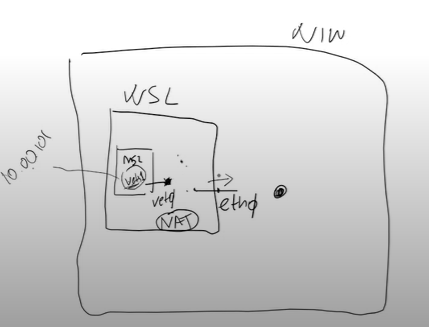

# 4.1) ***IFACE=\$(ip route | awk '/default/ {print $5; exit}')***

# 4.2 )  ***echo $IFACE***

Il problema di partenza è semplice: ns2 ha un indirizzo IP privato (10.0.0.101) che Internet non conosce e non sa come raggiungere. Se un pacchetto uscisse verso 8.8.8.8 con quell'indirizzo come sorgente, il server remoto non saprebbe dove rispondere — l'IP privato non è routable su Internet. Questo comando risolve esattamente quel problema.

Il comando si rivolge a Netfilter, il sottosistema del kernel Linux che intercetta i pacchetti in transito e può modificarli. iptables è lo strumento che si usa da terminale per configurare le regole di Netfilter. Con -t nat si specifica che si vuole lavorare sulla tabella dedicata alla traduzione degli indirizzi, non a quella del filtraggio.

La chain -A POSTROUTING indica il punto preciso del percorso del pacchetto in cui la regola interviene: dopo che il kernel ha già deciso dove instradare il pacchetto, nell'istante immediatamente prima che esca fisicamente dall'interfaccia di rete. È l'ultimo momento utile per modificare l'IP sorgente — se si intervenisse prima, il kernel non avrebbe ancora stabilito da quale interfaccia uscirà il pacchetto.

I due filtri -s 10.0.0.0/24 e -o "$UPLINK" definiscono con precisione a quali pacchetti si applica la regola: solo quelli che provengono dalla rete privata del namespace e che stanno uscendo verso Internet. Questo evita di alterare il traffico interno tra i due namespace, che non ha bisogno di alcuna traduzione.

Quando un pacchetto soddisfa entrambi i criteri, scatta l'azione -j MASQUERADE: il kernel legge l'IP corrente dell'interfaccia uscente (es. 172.20.130.147), sostituisce l'IP sorgente del pacchetto con quell'IP, e registra la traduzione nella tabella conntrack. Da quel momento il pacchetto viaggia su Internet come se provenisse direttamente dal main namespace.

Quando arriva la risposta da 8.8.8.8, è diretta a 172.20.130.147 — un IP che esiste e che Internet sa raggiungere. Il kernel consulta conntrack, trova la traduzione registrata in precedenza, e riconsegna il pacchetto a 10.0.0.101 dentro ns2. Il namespace privato riceve la risposta senza che né il mittente né il destinatario abbiano mai saputo dell'esistenza dell'indirizzo privato.

In sostanza, il main namespace fa da intermediario invisibile: presta il proprio IP pubblico al namespace privato, gestisce le connessioni per suo conto, e smista le risposte al mittente corretto — esattamente come fa il router di casa quando più dispositivi condividono un unico indirizzo IP verso Internet.

## 5.1 ***iptables -t nat -A POSTROUTING -s 10.0.0.0/24 -o eth0 -j MASQUERADE***

MASQUERO solo ai pacchetti che provengono dalla subnet privata di ns2 (-s 10.0.0.0/24) e che escono verso Internet (-o eth0), evitando di interessarsi ditraffico che non gli interessi


# 5.2 ***mkdir -p /etc/netns/ns2***
Creo la directory dove Linux cercherà la configurazione DNS specifica per ns2. Il -p evita errori se la directory esiste già.


# 5.3 ***sudo bash -c 'echo "nameserver 8.8.8.8" > /etc/netns/ns2/resolv.conf'***

Creo una ''rubrica'' in cui salvo il  server DNS al quale ns2 si deve rivolgere per avere l'IP con il quale lo si vuole far comunicare. Avendo diversi DNS avrei diversi potenziali IP con i quali comunicare e con i quali effettuare gli scambi definiti di seguito



# 6.1:

Una volta entrato nel contesto di rete di ns2 eseguo 3 ping ICMP verso 10.0.0.100, che è l'IP di veth0 nel main namespace — il gateway.
In poche parole sto tentando di verifacare la corretta implementazione del cavo che connette ns2 con il mainspace



In [ ]:
 sudo ip netns exec ns2 ping -c 3 10.0.0.100

# 6.2
 Provo a pingare  Google da dentro al namespace privato. Comunico direttamente con l'IP salvato in memoria per cui il punto qui è che se la comunicazione non avviene è perchè Google vede ancora l'indiirzzo IP di provenienza come privato ---> IN questo caso il MASQUERADE ha fallito, viceversa è riuscito
 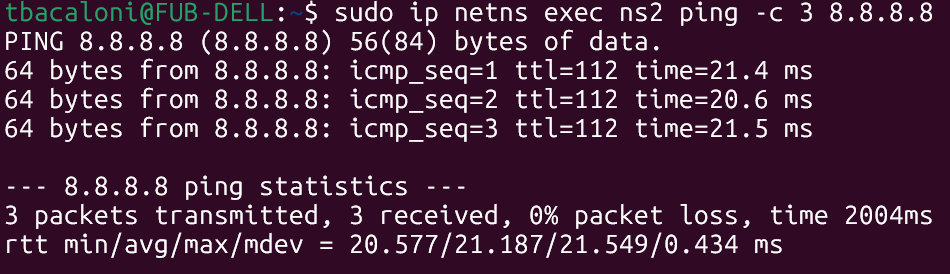



In [ ]:
sudo ip netns exec ns2 ping -c 3 8.8.8.8

#6.3
Testo una cosa diversa, cioè pingo  un hostname — non un IP: aggiungo  la verifica del DNS isolato per namespace. Prima di fare il ping, ns2 esegue internamente una query DNS verso 8.8.8.8  per chiedere: "qual è l'IP di www.google.com?". Solo dopo aver ricevuto la risposta DNS lo pinga.

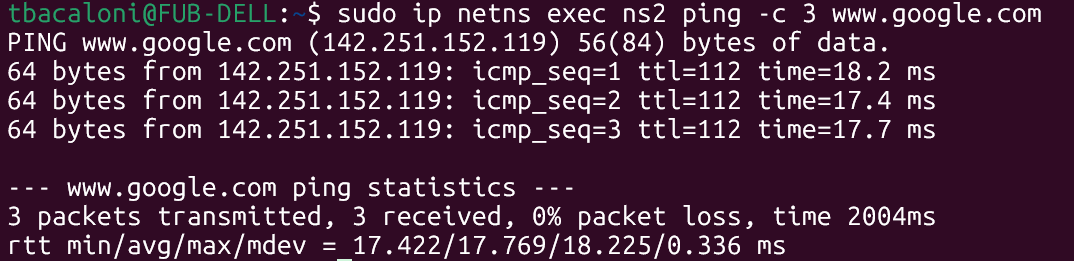

In [ ]:
 sudo ip netns exec ns2 ping -c 3 www.google.com

SyntaxError: Missing parentheses in call to 'exec'. Did you mean exec(...)? (3436535890.py, line 1)

# 7A: VERIFICA CORRETTO FUNZIONAMENTO MASQUERADE



1) Stampo la tabella  NAT di iptables, con la specifica dei contatori (-v) che servono per fare successivamente il confronto  dopo aver effettuato il ping.
L'output mostra che prima del ping ad aver attraversato la regola erano 4 pacchetti.

2) Genero 5 pacchetti ICMP dalla rete privata ns2 verso l'esterno (internt): ogni pacchetto percorre la catena NAT ed attiva la regola di MASQUERADE in POSTOURING

3) Ripeto lo stesso comando del punto 1) ed osservo che il test è riuscito perchè effettivamente dopo il test risultano esser transitati 5 pacchetti con un totale di byte aumentato proprio di 86

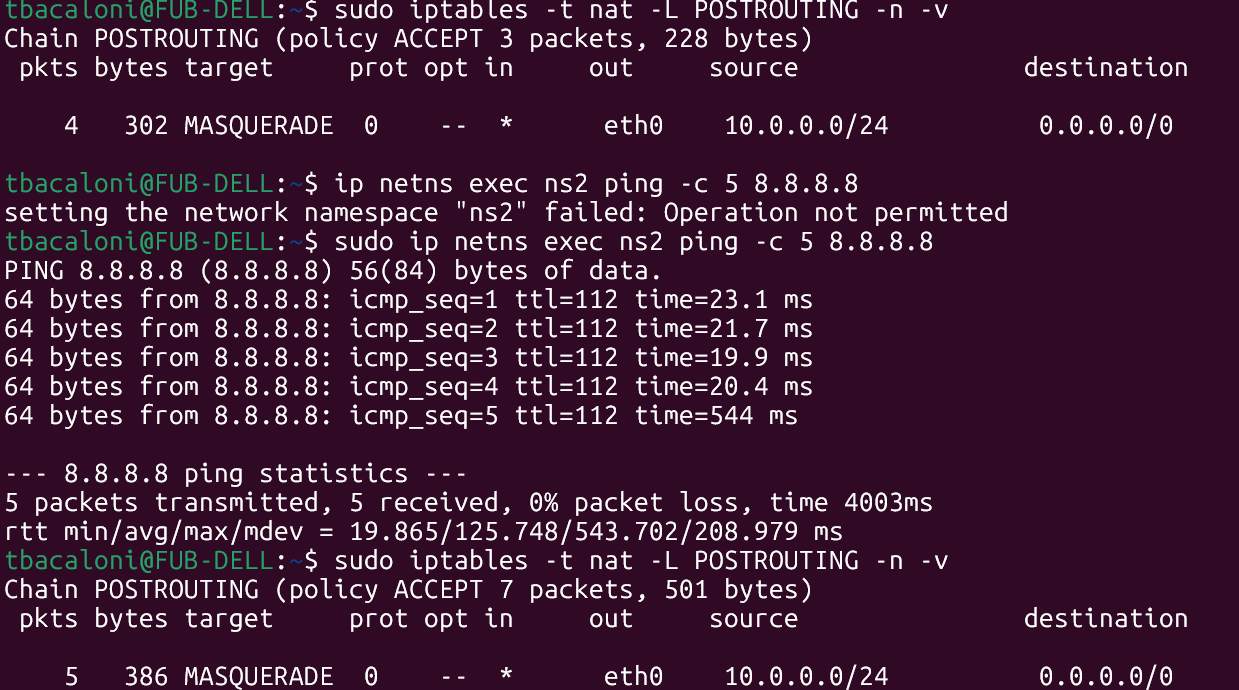

In [ ]:
# 1)
sudo iptables -t nat -L POSTOURING -n -v

# 2)
sudo ip netns exec ns2 ping -c 5 8.8.8.8

#3)
sudo iptables -t nat -L POSTOURING -n -v

# 7B VERIFICA CONNTRACK

Il punto 7B serve a osservare la tabella di stato del kernel per vedere il NAT avvenire in tempo reale. Dimostra due cose precise:

Che il kernel ha tracciato il flusso ICMP in entrambe le direzioni

Che MASQUERADE ha riscritto le tuple in modo asimmetrico: l'IP sorgente che entra (10.0.0.101) è diverso dall'IP che ha visto Internet (172.20.130.147)

Come esattamente il kernel ha tradotto sorgente/destinazione

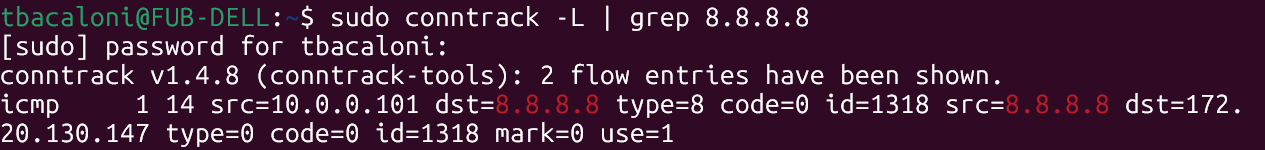

In [ ]:
# 1)
sudo apt update
sudo apt install -y conntrack

# 2)
sudo ip netns exec ns2 ping -c 10 8.8.8.8 &

# 3)
sudo conntrack -L | grep 8.8.8.8

# 7C TEST OSSERVAZIONE NAT

Testo quale sia l'IP del pacchetto che si invia PRIMA e DOPO il masquerade, per cui se i due IP risultano effettivamnete diversi il NAT ha fatto il suo dovere.
Servono tre terminali perchè due permettono di osservare il pacchetto prima e dopo rispettivamente, mentre l'altro serve per inviare il pacchetto.
Qui sotto si riportano solo  i comandi per tracciare nei primi due terminali.
Il risultato mostra chiaramente che [INTEGRAGREEEEEEEEE]


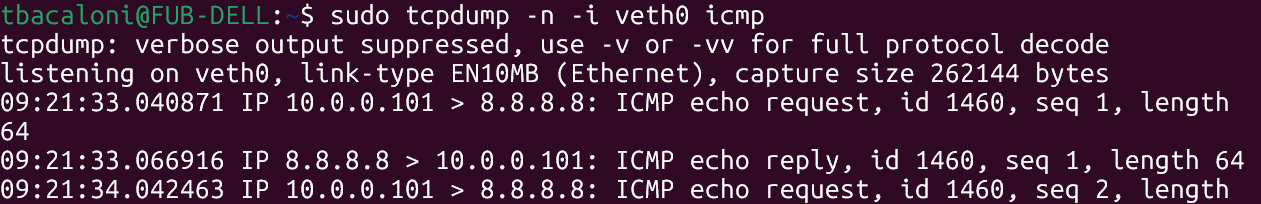


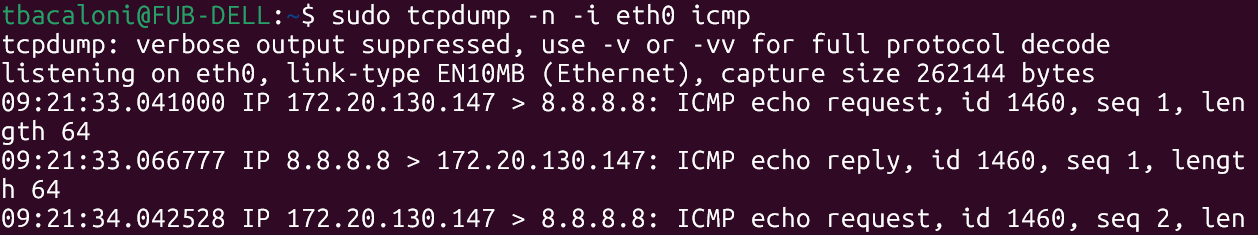

In [ ]:
# Terminale A (prima)
sudo tcpdump -n -i veth0 icmp

# Terminale B (dopo)
sudo tcpdump -n -i eth0 icmp

# Terminale C (lancio pacchetti)
ip netns exec ns2 ping -c 3 8.8.8.8

# 8 PRIMO TEST DI ABLAZIONE

Tolgo la  MASQUERADE lasciando ip_forward=1 attivo valutando se effettivamente il ping ad internet dall'interno del namespace privato ns2 fallisce come ci si aspetterebbe, essendo uno spazio privato e non pubblico.
Il test mostra che il 100% dei pacchetti inviati viene perso, evidenziando così che il MASQUERADE è essenziale e che se quindi prima la richesta funziona era grazie alla sua corretta attivazione

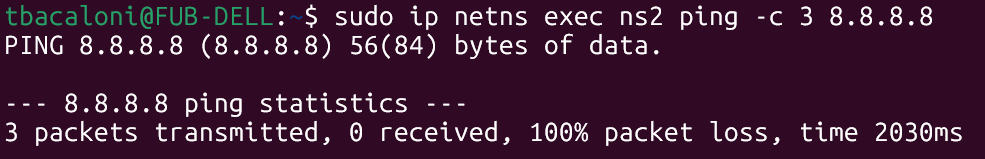



In [ ]:
# Tolgo la MASQUERADE
sudo iptables -t nat -D POSTROUTING -s 10.0.0.0/24 -o eth0 -j MASQUERADE

# Controllo che ip_forward sia ancora attivo, cioè che stampi 1
cat /proc/sys/net/ipv4/ip_forward

# ping a Google da dentro ns2 --> in teoria dovrebbe fallire, cioè si dovrebbero perdere tutti e 3 i pacchetti
sudo ip netns exec ns2 ping -c 3 8.8.8.8


# Rimetto la MASQUERADE oer dopo
sudo iptables -t nat -A POSTROUTING -s 10.0.0.0/24 -o eth0 -j MASQUERADE

# 9 SECONDO TEST DI ABLAZIONE
Il pacchetto NON arriva mai su eth0
  MASQUERADE non viene mai raggiunto (iptables POSTROUTING
  non viene attraversato se il kernel droppa prima)
  tcpdump su eth0: silenzio totale

  In pratica: senza ip_forward, il kernel non porta mai il pacchetto alla catena POSTROUTING di iptables. MASQUERADE è lì, pronto, ma il pacchetto viene buttato prima ancora di incontrarlo — come avere il timbro postale pronto ma il pacco viene distrutto all'ingresso dell'ufficio.



In [ ]:
# Disabilito ip_forward
sudo sysctl -w net.ipv4.ip_forward=0

#Verifico MASQUERADE
sudo iptables -t nat -L POSTROUTING -n -v

# RIprovo il ping e vediamo
sudo ip netns exec ns2 ping -c 3 8.8.8.8

## TCPDUMP PER VEDERE LE DIFFERENZE

# Terminale A — interfaccia interna
sudo tcpdump -n -i veth0 icmp

# Terminale B — interfaccia esterna
sudo tcpdump -n -i eth0 icmp

# Terminale C - ping dei 3 pacchetti
sudo ip netns exec ns2 ping -c 3 8.8.8.8

#RIPRISTINO TUTTO
sudo sysctl -w net.ipv4.ip_forward=1


# 10: DNAT PER SERVIZIO IN NS2

L'esperimento dimostra che Linux tratta i network namespace come macchine di rete completamente separate, ognuna con il proprio stack IP, interfacce e routing table — esattamente come se fossero computer fisici distinti collegati via cavo, ma tutto dentro una singola macchina reale.
Le coppie veth sono cavi virtuali: ogni pacchetto che entra da un capo esce dall'altro. Il main namespace fa da router centrale tra Internet e i due namespace.
Step 3 — entrambi escono su Internet
text
Questo dimostra che il NAT MASQUERADE funziona: il main namespace traduce gli IP privati (10.0.0.x, 10.0.1.x) nel proprio IP pubblico prima di spedire il pacchetto su eth0. Dal punto di vista di Internet sembra che sia il main namespace a fare le richieste, non ns2 o ns4.

Step 4 — isolamento inter-namespace
Questo dimostra che le regole DROP su FORWARD bloccano il routing tra le due subnet. Anche se il main namespace fisicamente potrebbe fare da router (ha entrambe le route), le regole iptables impediscono che i pacchetti passino da una subnet all'altra. È la stessa logica di una VLAN in una rete aziendale: macchine su subnet diverse non si parlano senza un firewall che lo permetta esplicitamente.

Test web server — raggiungibilità diretta
Questo dimostra che il main namespace raggiunge direttamente ns2 via veth0, senza NAT né DNAT, perché la route 10.0.0.0/24 dev veth0 è già presente nella sua routing table. Il log 10.0.0.100 - - GET / 200 conferma che la richiesta è arrivata da veth0 (IP 10.0.0.10
Ogni namespace ha la propria visione della rete: ns2 non sa che ns4 esiste, e viceversa. Solo il main namespace vede entrambi. Questo è esattamente il meccanismo che Docker usa per isolare i container: ogni container vive nel proprio network namespace e comunica con l'esterno solo attraverso regole NAT controllate dall'host.

In [ ]:
# STEP 0: pulizia preventiva porta 8000 in ns2
sudo ip netns exec ns2 pkill -f "http.server" 2>/dev/null; sleep 1

# STEP 1: avvia web server in ns2
sudo ip netns exec ns2 python3 -m http.server 8000 &

# STEP 2: abilita sysctl
sudo sysctl -w net.ipv4.ip_forward=1
sudo sysctl -w net.ipv4.conf.all.route_localnet=1

# STEP 3: regola DNAT su OUTPUT
sudo iptables -t nat -A OUTPUT -p tcp -d 127.0.0.1 --dport 8080 -j DNAT --to 10.0.0.101:8000

# STEP 4: testa
curl http://127.0.0.1:8080

# STEP 5: teardown
sudo iptables -t nat -D OUTPUT -p tcp -d 127.0.0.1 --dport 8080 -j DNAT --to 10.0.0.101:8000
sudo sysctl -w net.ipv4.conf.all.route_localnet=0
sudo ip netns exec ns2 pkill -f "http.server"

In [ ]:
# ESTENSIONE B

In [ ]:
# STEP 1: avvia un web server dentro ns2
sudo ip netns exec ns2 python3 -m http.server 8000 &

# STEP 2: aggiungi la regola DNAT sul main namespace
sudo iptables -t nat -A PREROUTING -p tcp --dport 8080 -j DNAT --to 10.0.0.101:8000

# STEP 3: assicurati che ip_forward sia attivo
sudo sysctl -w net.ipv4.ip_forward=1

# STEP 4: testa dal main namespace
curl http://127.0.0.1:8080
# Risposta attesa: listing HTML della directory corrente di ns2

# STEP 5: teardown dell'estensione
sudo iptables -t nat -D PREROUTING -p tcp --dport 8080 -j DNAT --to 10.0.0.101:8000
sudo ip netns exec ns2 kill %1   # ferma il web server

# VALUTAZIONE DI COME STO MESSO

In [ ]:
# 1. Rimuovi ns3 residuo
sudo ip netns del ns3

# 2. Azzera completamente la chain FORWARD (rimuove tutte le regole)
sudo iptables -F FORWARD

# 3. Riporta la policy FORWARD a ACCEPT (default)
sudo iptables -P FORWARD ACCEPT

# 4. Verifica che la NAT sia pulita (la regola per 10.0.0.0/24 va tenuta se ns2 è ancora attivo)
sudo iptables -t nat -L POSTROUTING -n --line-numbers

# PULIZIA

In [ ]:
# 1. Rimuovi ns3 residuo
sudo ip netns del ns3

# 2. Azzera completamente la chain FORWARD (rimuove tutte le regole)
sudo iptables -F FORWARD

# 3. Riporta la policy FORWARD a ACCEPT (default)
sudo iptables -P FORWARD ACCEPT

# 4. Verifica che la NAT sia pulita (la regola per 10.0.0.0/24 va tenuta se ns2 è ancora attivo)
sudo iptables -t nat -L POSTROUTING -n --line-numbers

## ESTENSIONE B
## Network Namespace e Isolamento di Rete in Linux

### Cosa si vuole dimostrare

L'esperimento mostra come Linux permetta di creare ambienti di rete completamente separati all'interno della stessa macchina fisica. L'obiettivo è duplice: dimostrare che due "macchine virtuali di rete" (i namespace) possono comunicare con Internet indipendentemente, e al tempo stesso dimostrare che possono essere isolate l'una dall'altra come se fossero su reti fisicamente distinte. Questo è esattamente il meccanismo che sta alla base di tecnologie come Docker e Kubernetes, dove ogni container vive nel proprio spazio di rete.

***

### Perché è rilevante

In una rete aziendale o in un sistema di container, è fondamentale che due servizi possano raggiungere Internet senza però potersi raggiungere direttamente tra loro, a meno che non sia esplicitamente autorizzato. Questo esperimento riproduce in miniatura quella logica: il main namespace fa da router e firewall centrale, decide chi può parlare con chi e chi può uscire su Internet, esattamente come farebbe un router con VLAN in una rete reale.

***

### La costruzione dell'ambiente

Il primo passo consiste nel creare un secondo namespace chiamato ns4, collegarlo al main namespace tramite una coppia di interfacce virtuali e configurarne gli indirizzi IP. Si può immaginare questa operazione come il collegare fisicamente un nuovo computer alla rete tramite un cavo: finché il cavo non è collegato e le interfacce non sono configurate con indirizzi IP coerenti, nessuna comunicazione è possibile. A ns4 viene anche assegnata una rotta di default che punta al main namespace, esattamente come un computer configura il gateway del router di casa.

***

### Il NAT e l'accesso a Internet

Una volta costruita la topologia fisica, il secondo passo abilita l'uscita su Internet per ns4. I namespace usano indirizzi IP privati (del tipo 10.x.x.x) che non sono routable su Internet: nessun server esterno saprebbe come rispondere a un pacchetto proveniente da un indirizzo privato. Il meccanismo MASQUERADE risolve questo problema sostituendo l'indirizzo privato di ns4 con l'indirizzo pubblico del main namespace ogni volta che un pacchetto esce verso Internet. Dal punto di vista esterno, è come se fosse il main namespace stesso a fare la richiesta. Questo è identico al NAT che fa il router di casa quando manda il traffico del tuo laptop su Internet.

***

### L'isolamento tra namespace

Il terzo passo è il più interessante dal punto di vista concettuale. Con ip_forward abilitato, il main namespace si comporta come un router a tutti gli effetti: vede entrambe le subnet di ns2 e ns4 e naturalmente inoltrerebbe il traffico tra le due. Per impedirlo vengono aggiunte regole esplicite che bloccano qualsiasi pacchetto che tenti di passare da una subnet all'altra. Il risultato è che ns2 e ns4 possono entrambi parlare con il mondo esterno, ma non si "vedono" tra loro: i loro pacchetti vengono scartati silenziosamente dal kernel nel momento in cui attraversano il firewall centrale.

***

### La verifica

I test di verifica hanno un valore didattico preciso. Il ping verso 8.8.8.8 che riesce da entrambi i namespace conferma che tutta la catena NAT funziona correttamente: il pacchetto parte dal namespace, attraversa il cavo virtuale, viene mascherato dal main namespace, raggiunge Internet e torna indietro. Il ping tra i due namespace che fallisce con 100% di packet loss conferma invece che le regole di blocco sono attive e posizionate correttamente nella catena di forwarding. Non è un errore: è esattamente il comportamento desiderato.

***

### Il teardown

La pulizia finale ha anch'essa un valore dimostrativo: mostra che l'intero ambiente è effimero e reversibile. Eliminare il namespace rimuove automaticamente le sue interfacce interne; rimuovere le regole iptables ripristina il comportamento di routing originale; eliminare le interfacce veth nel main namespace smonta l'ultimo residuo dell'infrastruttura. Dopo il teardown, la macchina è esattamente nello stato in cui era prima dell'esperimento, senza tracce residue.

In [ ]:
#!/bin/bash
# ============================================================
# ESERCIZIO: ns4 con subnet isolata (10.0.1.0/24)
# Prerequisito: ns2 già attivo su 10.0.0.0/24
# ============================================================

# STEP 1: crea ns4 e la coppia veth
sudo ip netns add ns4
sudo ip link add veth2 type veth peer name veth3
sudo ip link set veth3 netns ns4

# Configura veth2 nel main namespace
sudo ip addr add 10.0.1.100/24 dev veth2
sudo ip link set veth2 up

# Configura veth3 in ns4
sudo ip netns exec ns4 ip addr add 10.0.1.101/24 dev veth3
sudo ip netns exec ns4 ip link set veth3 up
sudo ip netns exec ns4 ip link set lo up
sudo ip netns exec ns4 ip route add default via 10.0.1.100

# STEP 2: NAT per la subnet di ns4
sudo iptables -t nat -A POSTROUTING -s 10.0.1.0/24 -o eth0 -j MASQUERADE

# STEP 3: blocca il forwarding inter-subnet (ip_forward=1 farebbe da router)
sudo iptables -I FORWARD 1 -s 10.0.0.0/24 -d 10.0.1.0/24 -j DROP
sudo iptables -I FORWARD 2 -s 10.0.1.0/24 -d 10.0.0.0/24 -j DROP

# STEP 4: verifica uscita Internet
sudo ip netns exec ns2 ping -c 2 8.8.8.8   # deve funzionare
sudo ip netns exec ns4 ping -c 2 8.8.8.8   # deve funzionare

# STEP 5: verifica isolamento inter-namespace
sudo ip netns exec ns2 ping -c 2 10.0.1.101  # deve fallire
sudo ip netns exec ns4 ping -c 2 10.0.0.101  # deve fallire

# ============================================================
# STEP 6: teardown pulito
# ============================================================
sudo ip netns del ns4
sudo iptables -t nat -D POSTROUTING -s 10.0.1.0/24 -o eth0 -j MASQUERADE
sudo iptables -D FORWARD -s 10.0.0.0/24 -d 10.0.1.0/24 -j DROP
sudo iptables -D FORWARD -s 10.0.1.0/24 -d 10.0.0.0/24 -j DROP
sudo ip link del veth2  # rimuove anche veth3 automaticamente

RIVEDO COME STO MESSO

In [ ]:
sudo ip netns list
# ns2 (id: 1)
# ns-priv (id: 0)

sudo iptables -L FORWARD -n --line-numbers
# Chain FORWARD (policy ACCEPT)
# num  target  prot opt source  destination
# (vuota)

ip link show type veth
# 6: veth0@if5: ... link-netns ns2   ← solo questa, corretta

# 10: TEARDOWN

In [ ]:
sudo ./scripts/teardown.sh